In [1]:
import os
import glob
import sys

import itertools

import numpy as np
import pandas as pd
import scipy.stats as ss
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns

from tqdm.auto import tqdm as tqdm_auto
from tqdm.notebook import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader
import pytorch_lightning as pl

from IPython.display import clear_output

In [2]:
# Load all models
from optimus5 import Optimus5PrimeOriginal
from optimus5_25 import Optimus5Prime25
from mttrans import RL_gru
from framepool import FramePool
from dream_wrappers import DreamRNNFacade, DreamAttnFacade

In [3]:
sys.path.append("../../predictor/model/")
import utrdata_cl as utrdata
from pl_regressor import RNARegressor
from legnet_classifier import LegNetClassifier

In [4]:
utr_type = "utr5"
seqsize = 50 if utr_type == "utr5" else 240

## Loading data

In [5]:
PATH_FROM = f"../../predictor/library2/{utr_type.upper()}_zscores_2024-06-04.csv"
df = pd.read_csv(PATH_FROM)

In [6]:
num_classes = df["cell_type"].unique().shape[0]
num_classes

5

In [7]:
batch_size = 128

In [8]:
num_workers = 32

In [9]:
test_set = utrdata.UTRData(
    df=df,
    predict_cols=["mass_center"],
    construct_type=utr_type,
    features=("sequence", "conditions"),
    augment=False,
    augment_test_time=False,
    augment_kws=dict(
        extend_left=0,
        extend_right=0,
        shift_left=0,
        shift_right=0,
        revcomp=False,
    ),
)
dl_test = DataLoader(
    test_set,
    batch_size=batch_size,
    num_workers=num_workers,
    shuffle=False,
    drop_last=False
)

parade_test_set = utrdata.UTRData(
    df=df,
    construct_type=utr_type,
    features=("sequence", "positional", "conditions"),
    augment=False,
    augment_test_time=False,
    augment_kws=dict(
        extend_left=0,
        extend_right=0,
        shift_left=0,
        shift_right=0,
        revcomp=False,
    ),
)
parade_dl_test = DataLoader(
    parade_test_set,
    batch_size=batch_size,
    num_workers=num_workers,
    shuffle=False,
    drop_last=False
)

### Loading models

In [10]:
legnet_checkpoint = glob.glob(f"../../predictor/regression_multiple/saved_models/model-{utr_type}*.ckpt")[0]
model_checkpoints = {os.path.basename(os.path.dirname(path)): path for path in glob.glob(f"./saved_models/{utr_type}/*/*.ckpt")}
model_checkpoints

{'DreamAttnFacade': './saved_models/utr5/DreamAttnFacade/epoch=4-step=13505.ckpt',
 'DreamRNNFacade': './saved_models/utr5/DreamRNNFacade/epoch=16-step=45917.ckpt',
 'Optimus5PrimeOriginal': './saved_models/utr5/Optimus5PrimeOriginal/epoch=12-step=8775.ckpt',
 'FramePool': './saved_models/utr5/FramePool/epoch=10-step=7425.ckpt',
 'Optimus5Prime25': './saved_models/utr5/Optimus5Prime25/epoch=10-step=7425.ckpt',
 'RL_gru': './saved_models/utr5/RL_gru/epoch=99-step=270100.ckpt'}

In [11]:
models = dict()
for model_name, ckpt_path in model_checkpoints.items():
    ckpt = torch.load(ckpt_path)
    loaded_model = RNARegressor(**ckpt["hyper_parameters"])
    loaded_model.load_state_dict(ckpt["state_dict"])
    models[model_name] = loaded_model
legnet_ckpt = torch.load(legnet_checkpoint)
legnet_model = RNARegressor(**legnet_ckpt["hyper_parameters"])
legnet_model.load_state_dict(legnet_ckpt["state_dict"])

<All keys matched successfully>

In [12]:
progressbar_callback = pl.callbacks.TQDMProgressBar(refresh_rate=0.5)
trainer = pl.Trainer(
    callbacks=[progressbar_callback],
    accelerator="gpu",
    devices=[0],
    deterministic=True,
    num_sanity_val_steps=0,
)
result_df = df[["seq", "cell_type", "mass_center"]].copy()

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
IPU available: False, using: 0 IPUs
HPU available: False, using: 0 HPUs


In [13]:
for model_name, model_instance in models.items():
    print(model_name)
    prediction = trainer.predict(model=model_instance, dataloaders=dl_test)
    test_pred, test_real = zip(*prediction)
    test_pred = torch.concat(test_pred).numpy()
    # test_real = torch.concat(test_real).numpy()
    result_df[model_name] = test_pred[:, 0]

You are using a CUDA device ('NVIDIA GeForce RTX 3090') that has Tensor Cores. To properly utilize them, you should set `torch.set_float32_matmul_precision('medium' | 'high')` which will trade-off precision for performance. For more details, read https://pytorch.org/docs/stable/generated/torch.set_float32_matmul_precision.html#torch.set_float32_matmul_precision
Missing logger folder: /home/arsen_l/rna-legnet/wp6_clean_repo/parade-private/benchmark/model-collection/lightning_logs


DreamAttnFacade


LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1]


Predicting: 0it [00:00, ?it/s]

You are using a CUDA device ('NVIDIA GeForce RTX 3090') that has Tensor Cores. To properly utilize them, you should set `torch.set_float32_matmul_precision('medium' | 'high')` which will trade-off precision for performance. For more details, read https://pytorch.org/docs/stable/generated/torch.set_float32_matmul_precision.html#torch.set_float32_matmul_precision
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1]


...

Predicting: 0it [00:00, ?it/s]

You are using a CUDA device ('NVIDIA GeForce RTX 3090') that has Tensor Cores. To properly utilize them, you should set `torch.set_float32_matmul_precision('medium' | 'high')` which will trade-off precision for performance. For more details, read https://pytorch.org/docs/stable/generated/torch.set_float32_matmul_precision.html#torch.set_float32_matmul_precision
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1]


RL_gru


Traceback (most recent call last):
  File "/home/arsen_l/.miniconda3/envs/ml/lib/python3.11/multiprocessing/util.py", line 300, in _run_finalizers
    finalizer()
  File "/home/arsen_l/.miniconda3/envs/ml/lib/python3.11/multiprocessing/util.py", line 224, in __call__
    res = self._callback(*self._args, **self._kwargs)
          ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/home/arsen_l/.miniconda3/envs/ml/lib/python3.11/multiprocessing/util.py", line 133, in _remove_temp_dir
    rmtree(tempdir)
  File "/home/arsen_l/.miniconda3/envs/ml/lib/python3.11/shutil.py", line 738, in rmtree
    onerror(os.rmdir, path, sys.exc_info())
  File "/home/arsen_l/.miniconda3/envs/ml/lib/python3.11/shutil.py", line 736, in rmtree
    os.rmdir(path, dir_fd=dir_fd)
OSError: [Errno 39] Directory not empty: '/tmp/pymp-ocxp8pqr'


Predicting: 0it [00:00, ?it/s]

In [14]:
print("LegNetClassifier")
prediction = trainer.predict(model=legnet_model, dataloaders=parade_dl_test)
test_pred, test_real = zip(*prediction)
test_pred = torch.concat(test_pred).numpy()
# test_real = torch.concat(test_real).numpy()
result_df["LegNetClassifier"] = test_pred[:, 1]
result_df["LegNetClassifier_delta"] = test_pred[:, 0]

You are using a CUDA device ('NVIDIA GeForce RTX 3090') that has Tensor Cores. To properly utilize them, you should set `torch.set_float32_matmul_precision('medium' | 'high')` which will trade-off precision for performance. For more details, read https://pytorch.org/docs/stable/generated/torch.set_float32_matmul_precision.html#torch.set_float32_matmul_precision


LegNetClassifier


LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1]


Predicting: 0it [00:00, ?it/s]

In [15]:
result_df_r = pd.concat({"pred_mass_center": result_df.drop(["seq", "cell_type", "mass_center"], axis=1)}, axis=1)
for i, col in enumerate(["seq", "cell_type", "mass_center"]):
    result_df_r.insert(i, col, result_df[col])
result_df_r

seq cell_type  \
                                                                     
0      AAAAAAAATGTGACGGCGGCGGCGGCGGCGGCGGCGGCAGCGGCGG...        c1   
1      AAAAAAAATGTGACGGCGGCGGCGGCGGCGGCGGCGGCAGCGGCGG...       c17   
2      AAAAAAAATGTGACGGCGGCGGCGGCGGCGGCGGCGGCAGCGGCGG...        c2   
3      AAAAAAAATGTGACGGCGGCGGCGGCGGCGGCGGCGGCAGCGGCGG...        c4   
4      AAAAAAAATGTGACGGCGGCGGCGGCGGCGGCGGCGGCAGCGGCGG...        c6   
...                                                  ...       ...   
50865  TTTTTTGTGTGCGTGCACGTCCTCGTTATCGTGCATCCATGGCGCG...        c1   
50866  TTTTTTGTGTGCGTGCACGTCCTCGTTATCGTGCATCCATGGCGCG...       c17   
50867  TTTTTTGTGTGCGTGCACGTCCTCGTTATCGTGCATCCATGGCGCG...        c2   
50868  TTTTTTGTGTGCGTGCACGTCCTCGTTATCGTGCATCCATGGCGCG...        c4   
50869  TTTTTTGTGTGCGTGCACGTCCTCGTTATCGTGCATCCATGGCGCG...        c6   

      mass_center pred_mass_center                                       \
                   DreamAttnFacade DreamRNNFacade Optimus5PrimeOriginal   
0        2.677959         2.089592       2.275520              2.212436   
1        2.569722         2.035427       2.186499              2.149429   
2        2.109072         2.014704       2.170969              2.160423   
3        1.913060         2.061179       2.199306              2.199667   
4        2.214925         1.994662       2.150944              2.268024   
...           ...              ...            ...                   ...   
50865    2.635636         2.515516       2.170225              2.693273   
50866    2.506005         2.609045       2.304391              2.936620   
50867    2.536861         2.513389       2.200554              2.644745   
50868    2.458855         2.523547       2.240421              2.640469   
50869    2.313986         2.457783       2.197148              2.629319   

                                                            \
      FramePool Optimus5Prime25    RL_gru LegNetClassifier   
0      2.153630        2.228504  2.209441         2.235363   
1      2.064031        2.197854  2.170925         2.374463   
2      2.100484        2.116456  2.178450         2.172391   
3      2.119982        2.195448  2.216378         2.328313   
4      2.107987        2.240099  2.192406         2.336070   
...         ...             ...       ...              ...   
50865  2.432009        2.173089  2.337415         2.368688   
50866  2.439218        2.292916  2.382396         2.555840   
50867  2.414111        2.222880  2.353360         2.420759   
50868  2.324522        2.190310  2.347258         2.403861   
50869  2.336416        2.145473  2.297299         2.281163   

                              
      LegNetClassifier_delta  
0                   0.020645  
1                  -0.073548  
2                   0.003713  
3                  -0.008878  
4                  -0.019559  
...                      ...  
50865              -0.036284  
50866               0.054916  
50867              -0.022615  
50868              -0.016199  
50869              -0.065204  

[50870 rows x 11 columns]

In [16]:
result_df_r.to_parquet(f"benchmark_preds_{utr_type}_lib2.parquet")

In [17]:
correlations = result_df.groupby("cell_type")[["mass_center"] + list(models.keys()) + ["LegNetClassifier"]].corr()["mass_center"].unstack(0).drop("mass_center", axis=0)
correlations["mean"] = result_df.groupby("seq")[["mass_center"] + list(models.keys()) + ["LegNetClassifier"]].mean().corr()["mass_center"].drop("mass_center")
correlations

cell_type,c1,c17,c2,c4,c6,mean
DreamAttnFacade,0.567210,0.625177,0.510346,0.565858,0.381754,0.686861
DreamRNNFacade,0.566006,0.622259,0.479315,0.548859,0.383642,0.674578
Optimus5PrimeOriginal,0.562153,0.615935,0.487932,0.546659,0.395983,0.685604
FramePool,0.564246,0.620098,0.495497,0.574638,0.399146,0.698276
Optimus5Prime25,0.547665,0.576986,0.443097,0.514950,0.361637,0.637011
RL_gru,0.522077,0.550233,0.426336,0.501990,0.356310,0.625874
LegNetClassifier,0.571283,0.623088,0.523317,0.584193,0.388581,0.704422


<Axes: ylabel='cell_type'>

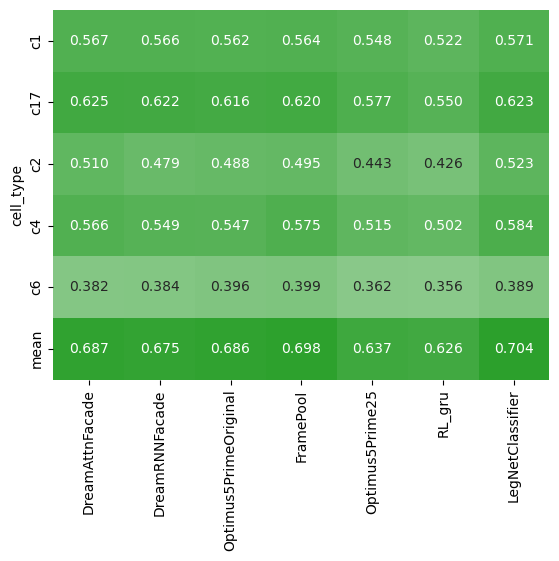

In [18]:
sns.heatmap(correlations.T, cmap=sns.color_palette("light:C2", n_colors=1000, as_cmap=True), vmin=0,
            annot=True, fmt=".3f", cbar=False)

In [19]:
correlations.mean(axis=1).sort_values(ascending=False)

LegNetClassifier         0.565814
FramePool                0.558650
DreamAttnFacade          0.556201
Optimus5PrimeOriginal    0.549044
DreamRNNFacade           0.545776
Optimus5Prime25          0.513558
RL_gru                   0.497137
dtype: float64

In [20]:
list(zip(correlations.columns, correlations.index[correlations.values.argmax(axis=0)]))

[('c1', 'LegNetClassifier'),
 ('c17', 'DreamAttnFacade'),
 ('c2', 'LegNetClassifier'),
 ('c4', 'LegNetClassifier'),
 ('c6', 'FramePool'),
 ('mean', 'LegNetClassifier')]

---